In [1]:
import pandas as pd
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define our paths
zip_path = '/content/drive/MyDrive/MRI_PET_10_FEB_ADNI2.zip'
pet_base_dir = '/content/drive/MyDrive/ADNI_PET_Only'

# Create the output folders for our 2D PET images
os.makedirs(f"{pet_base_dir}/AD", exist_ok=True)
os.makedirs(f"{pet_base_dir}/CN", exist_ok=True)

# 3. Load the CSV from GOOGLE DRIVE (Update this path if needed)
csv_filename = '/content/drive/MyDrive/MRI_PET_10_FEB_ADNI2_2_10_2026.csv'
df = pd.read_csv(csv_filename)

# 4. Filter for ONLY PET scans
pet_df = df[df['Modality'] == 'PET']

# Create our dictionary for instant label lookup (Image ID -> AD or CN)
pet_label_map = dict(zip(pet_df['Image Data ID'], pet_df['Group']))

print(f"Setup Complete! Found {len(pet_label_map)} PET scans in the CSV.")
print("Drive mounted and folders created.")

Mounted at /content/drive
Setup Complete! Found 1311 PET scans in the CSV.
Drive mounted and folders created.


In [2]:
!pip install pydicom

import zipfile
import pydicom
import numpy as np
import cv2
import re
from collections import defaultdict

print("Scanning ZIP for PET DICOM files...")

# First, we need to group all DICOM files by their Image ID
pet_groups = defaultdict(list)

with zipfile.ZipFile(zip_path, 'r') as zf:
    all_files = zf.namelist()

    for f in all_files:
        if f.endswith('.dcm'):
            img_id_match = re.search(r'I\d+', f)
            if img_id_match:
                img_id = img_id_match.group(0)
                # Only keep it if it's in our PET CSV list
                if img_id in pet_label_map:
                    pet_groups[img_id].append(f)

print(f"Found {len(pet_groups)} unique PET scans to process. Starting conversion...")

count = 0
with zipfile.ZipFile(zip_path, 'r') as zf:
    for img_id, file_list in pet_groups.items():
        group = pet_label_map[img_id]
        save_path = f"{pet_base_dir}/{group}/{img_id}.png"

        # Skip if already processed
        if not os.path.exists(save_path):
            try:
                # Sort the files alphabetically to ensure they are in order of depth
                file_list.sort()

                # Pick the middle slice
                mid_idx = len(file_list) // 2
                target_file = file_list[mid_idx]

                # Extract just this one DICOM file temporarily
                zf.extract(target_file, '/content/temp_pet')
                local_path = os.path.join('/content/temp_pet', target_file)

                # Read DICOM pixel data
                ds = pydicom.dcmread(local_path)
                pixel_array = ds.pixel_array.astype(float)

                # Normalize 0-255
                denom = np.max(pixel_array) - np.min(pixel_array)
                if denom == 0: denom = 1
                rescaled = (pixel_array - np.min(pixel_array)) / denom * 255

                # Save as PNG
                cv2.imwrite(save_path, rescaled.astype(np.uint8))

                # Clean up
                os.remove(local_path)

                count += 1
                if count % 20 == 0:
                    print(f"Successfully processed {count} PET images...")

            except Exception as e:
                print(f"Error on {img_id}: {e}")

print(f"PET Preprocessing Complete! Total processed: {count}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 25.6 MB/s eta 0:00:00
Scanning ZIP for PET DICOM files...
Found 1311 unique PET scans to process. Starting conversion...
Successfully processed 20 PET images...
Successfully processed 40 PET images...
Successfully processed 60 PET images...
Successfully processed 80 PET images...
Successfully processed 100 PET images...
Successfully processed 120 PET images...
Successfully processed 140 PET images...
Successfully processed 160 PET images...
Successfully processed 180 PET images...
Successfully processed 200 PET images...
Successfully processed 220 PET images...
Successfully processed 240 PET images...
Successfully processed 260 PET images...
Successfully processed 280 PET images...
Successfully processed 300 PET images...
Successfully processed 320 PET images...
Successfully processed 340 PET images...
Successfully processed 360 PET images...
Successfully processed 380 PET images...
Successfully processed 400 PET images...
Successf

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# 1. Path to your extracted 2D PET images
pet_base_dir = '/content/drive/MyDrive/ADNI_PET_Only'

# 2. Image Parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 16

# 3. Data Loading & Augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,    # 20% for testing
    rotation_range=10,
    zoom_range=0.1
)

print("Loading PET Training Data:")
train_generator = datagen.flow_from_directory(
    pet_base_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    color_mode='rgb'         # PET scans often have color maps, or OpenCV saves them as 3-channel
)

print("\nLoading PET Validation Data:")
val_generator = datagen.flow_from_directory(
    pet_base_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    color_mode='rgb'
)

# 4. Build the PET CNN Architecture
pet_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile the model
pet_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

print("\nStarting PET Model Training...")

# 5. Train the Model
EPOCHS = 15

history_pet = pet_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)

print("PET Training Complete!")

Loading PET Training Data:
Found 1050 images belonging to 2 classes.

Loading PET Validation Data:
Found 261 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Starting PET Model Training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.6020 - loss: 0.6900 - val_accuracy: 0.6130 - val_loss: 0.6809
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.6109 - loss: 0.6818 - val_accuracy: 0.6130 - val_loss: 0.6707
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.6131 - loss: 0.6703 - val_accuracy: 0.6130 - val_loss: 0.6647
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.6116 - loss: 0.6652 - val_accuracy: 0.6130 - val_loss: 0.6600
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 209s 2s/step - accuracy: 0.5830 - loss: 0.6748 - val_accuracy: 0.6130 - val_loss: 0.6703
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.6029 - loss: 0.6833 - val_accuracy: 0.6130 - val_loss: 0.6643
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.6064 - loss: 0.6658 - val_accuracy: 0.6130 - val_loss: 0.6517
Epoch 8/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.5970 - loss: 0.6626 - val_accuracy: 0.6130 - v

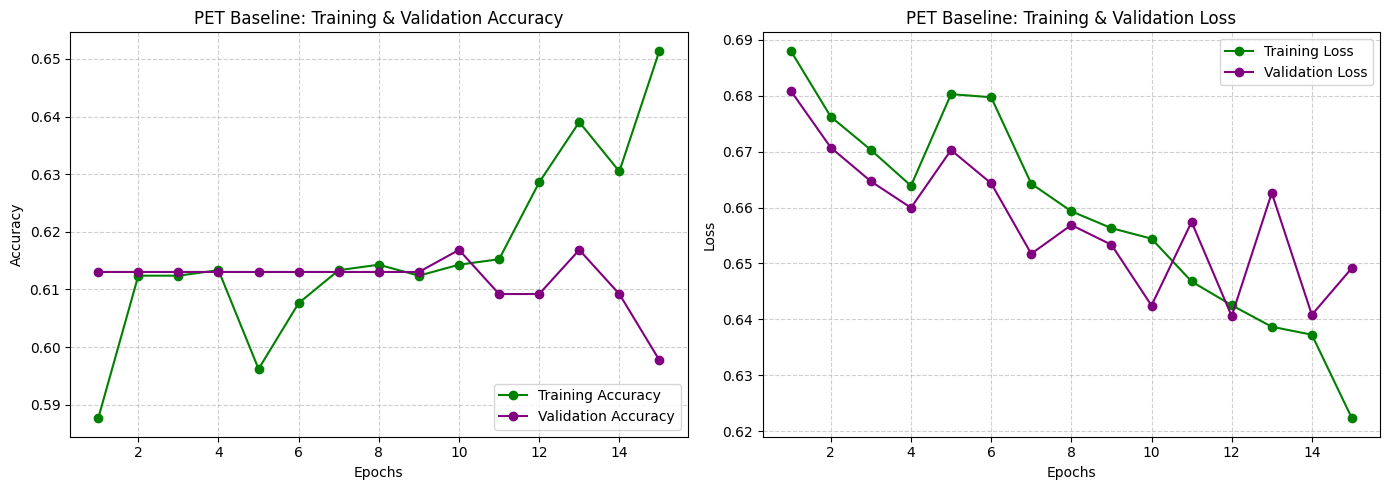

Generating predictions for PET Confusion Matrix...
Found 261 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


17/17 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step


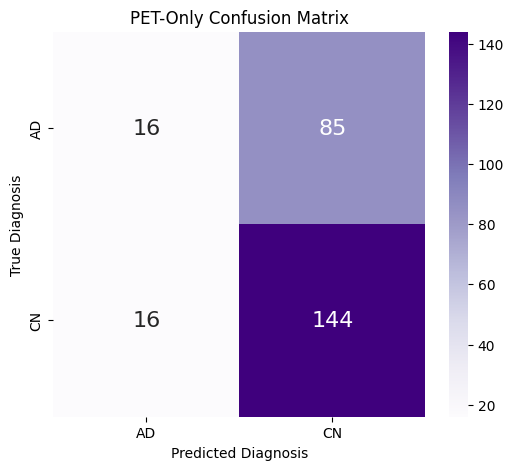


 PET-ONLY BASELINE CLASSIFICATION REPORT
              precision    recall  f1-score   support

          AD       0.50      0.16      0.24       101
          CN       0.63      0.90      0.74       160

    accuracy                           0.61       261
   macro avg       0.56      0.53      0.49       261
weighted avg       0.58      0.61      0.55       261



In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ---------------------------------------------------------
# 1. Plot Training vs. Validation Graphs (PET)
# ---------------------------------------------------------
acc = history_pet.history['accuracy']
val_acc = history_pet.history['val_accuracy']
loss = history_pet.history['loss']
val_loss = history_pet.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o', color='green')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o', color='purple')
plt.title('PET Baseline: Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o', color='green')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o', color='purple')
plt.title('PET Baseline: Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. Prepare Data for Confusion Matrix
# ---------------------------------------------------------
print("Generating predictions for PET Confusion Matrix...")

# Recreate the validation generator with shuffle=False
val_generator_pet_eval = datagen.flow_from_directory(
    pet_base_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    color_mode='rgb',
    shuffle=False
)

# Get predictions from the PET model
predictions_pet = pet_model.predict(val_generator_pet_eval)
predicted_classes_pet = (predictions_pet > 0.5).astype("int32")
true_classes_pet = val_generator_pet_eval.classes
class_labels_pet = list(val_generator_pet_eval.class_indices.keys())

# ---------------------------------------------------------
# 3. Plot Confusion Matrix
# ---------------------------------------------------------
cm_pet = confusion_matrix(true_classes_pet, predicted_classes_pet)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_pet, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_labels_pet, yticklabels=class_labels_pet,
            annot_kws={"size": 16})
plt.title('PET-Only Confusion Matrix')
plt.ylabel('True Diagnosis')
plt.xlabel('Predicted Diagnosis')
plt.show()

# ---------------------------------------------------------
# 4. Print the Official Classification Report
# ---------------------------------------------------------
print("\n" + "="*50)
print(" PET-ONLY BASELINE CLASSIFICATION REPORT")
print("="*50)
print(classification_report(true_classes_pet, predicted_classes_pet, target_names=class_labels_pet))